# Phase 3A: PPG-Only Classical Baseline, Evaluation & Error Analysis

**Project**: Cuffless Blood Pressure Estimation from PPG using MAX30102 + ESP32  
**Phase**: 3A — Classical Baselines & Empirical Error Analysis  
**Dataset**: PhysioNet MIMIC-II (via Kaggle Blood Pressure Dataset)  
**Input Modality**: Channel 0 (PPG only, 125 Hz, 1250 samples / 10-second window)  
**Ground Truth**: SBP and DBP derived from reference invasive ABP beats  
**Calibration**: **Zero calibration** (strictly calibration-free, subject-independent)  
**Partitioning**: Frozen Phase 2 Record-Level Splits (8,400 Train / 1,800 Val / 1,800 Test)  
**Scope**: Classical regression models (Dummy, Linear, Ridge, Random Forest, HistGradientBoosting). Deep learning is strictly prohibited in this phase.



In [1]:
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Setup project directories
NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

METRICS_DIR = CODE_DIR / "outputs" / "metrics"
FIGURES_DIR = CODE_DIR / "outputs" / "figures"
MODELS_DIR = CODE_DIR / "outputs" / "models"
REPORTS_DIR = CODE_DIR / "outputs" / "reports"
PREDICTIONS_DIR = CODE_DIR / "outputs" / "predictions"

print("Environment paths initialized.")



Environment paths initialized.


## 2. Frozen Dataset & Leakage-Control Verification

The Phase 2 dataset partition is strictly reused. We verify that:
1. No records overlap between train, validation, and test partitions.
2. Modeling-eligible windows meet dual-channel validity criteria.



In [2]:
split_file = CODE_DIR / "outputs" / "splits" / "record_split.csv"
manifest_file = CODE_DIR / "outputs" / "windows" / "window_manifest.csv"

df_split = pd.read_csv(split_file)
df_manifest = pd.read_csv(manifest_file)

train_recs = set(df_split[df_split['split'] == 'train']['record_id'])
val_recs = set(df_split[df_split['split'] == 'val']['record_id'])
test_recs = set(df_split[df_split['split'] == 'test']['record_id'])

assert len(train_recs.intersection(val_recs)) == 0, "Leakage: Train/Val overlap!"
assert len(train_recs.intersection(test_recs)) == 0, "Leakage: Train/Test overlap!"
assert len(val_recs.intersection(test_recs)) == 0, "Leakage: Val/Test overlap!"

df_eligible = df_manifest[df_manifest['modeling_eligible'] == True]
print(f"Verified 0 record leakage across {len(df_split):,} records.")
print(f"Total modeling-eligible windows: {len(df_eligible):,}")
for s in ['train', 'val', 'test']:
    sub = df_eligible[df_eligible['split'] == s]
    print(f"  {s.upper():<5}: {len(sub):,} windows across {sub['record_id'].nunique():,} unique records")



Verified 0 record leakage across 12,000 records.
Total modeling-eligible windows: 261,339
  TRAIN: 183,517 windows across 7,615 unique records
  VAL  : 39,461 windows across 1,628 unique records
  TEST : 38,361 windows across 1,621 unique records


## 3. BP Target Range Distribution & Coverage Audit Prior to Training

Before fitting any models, we audit the target blood pressure distributions across partitions to contextualize later model performance across clinical stages.



In [3]:
df_bp_cov = pd.read_csv(METRICS_DIR / "bp_range_coverage.csv")
display(df_bp_cov)



,target,range,train_count,validation_count,test_count,train_percentage,validation_percentage,test_percentage
0,SBP,<90,3485,800,696,1.899007,2.027318,1.814343
1,SBP,90-119,65847,13981,12679,35.880600,35.429918,33.051797
2,SBP,120-139,57927,13112,12759,31.564923,33.227744,33.260343
3,SBP,140-159,38009,7973,8512,20.711433,20.204759,22.189203
4,SBP,>=160,18249,3595,3715,9.944038,9.110261,9.684315
5,DBP,<60,57699,12570,11647,31.440684,31.854236,30.361565
6,DBP,60-79,104252,22638,21716,56.807816,57.368034,56.609577
7,DBP,80-89,15076,2851,3216,8.215043,7.224855,8.383515
8,DBP,90-99,4249,963,1150,2.315317,2.440384,2.997836
9,DBP,>=100,2241,439,632,1.221140,1.112491,1.647507


## 4. Input Representations & Feature Engineering

Three explicit physiological representation branches were evaluated:
- **Branch A (Amplitude-Preserving PPG)**: 14 scale-dependent features (mean, std, RMS, peak-to-peak, pulse amplitude, IQR).
- **Branch B (Normalized Morphology PPG)**: 26 scale-invariant features (pulse width, rise/decay times, slopes, VPG, APG, spectral entropy).
- **Branch C (Combined Representation)**: 40 fused features.

All features are tested against forbidden substring leakage (`abp`, `ecg`, `sbp`, `dbp`, `map`, `ptt`, `pat`, `calibration`).



In [4]:
from modeling.features import BRANCH_A_FEATURES, BRANCH_B_FEATURES, BRANCH_C_FEATURES, FEATURE_GROUPS, assert_feature_integrity

print(f"Branch A Feature Count: {len(BRANCH_A_FEATURES)}")
print(f"Branch B Feature Count: {len(BRANCH_B_FEATURES)}")
print(f"Branch C Feature Count: {len(BRANCH_C_FEATURES)}")
print("\nFeature Groups:")
for grp, feats in FEATURE_GROUPS.items():
    print(f"  {grp:<15}: {len(feats)} features ({', '.join(feats[:3])}...)")

assert_feature_integrity(BRANCH_C_FEATURES)
print("\nIntegrity Check: PASSED (0 forbidden terms).")



Branch A Feature Count: 14
Branch B Feature Count: 26
Branch C Feature Count: 40

Feature Groups:
  A_basic        : 11 features (mean_a, std_a, var_a...)
  B_timing       : 6 features (pulse_count, hr_bpm, ibi_mean...)
  C_morphology   : 7 features (pulse_amp_median_a, pulse_amp_iqr_a, pulse_amp_cv_a...)
  D_vpg          : 5 features (vpg_max, vpg_min, vpg_std...)
  E_apg          : 4 features (apg_max, apg_min, apg_std...)
  F_spectral     : 3 features (dominant_freq, pulse_band_power, spectral_entropy...)

Integrity Check: PASSED (0 forbidden terms).


## 5. Cumulative Feature-Group Ablation Study

We evaluate cumulative feature groups (Ablations 0 to 6) on the validation set using identical Phase 2 splits to determine which physiological information groups contribute genuine predictive power.



,ablation,feature_count,target,MAE,RMSE,R2,bias,error_sd
0,Ablation_0_Dummy,0,SBP,17.619353,21.697091,0.000000,0.389134,21.693601
1,Ablation_0_Dummy,0,DBP,8.453226,10.926590,0.000000,0.091871,10.926203
2,Ablation_1_Basic,11,SBP,15.946880,20.155457,0.136779,0.563661,20.147573
3,Ablation_1_Basic,11,DBP,8.044298,10.545412,0.068488,0.180920,10.543860
4,Ablation_2_Basic_Timing,17,SBP,15.343296,19.559282,0.187090,0.590940,19.550353
5,Ablation_2_Basic_Timing,17,DBP,7.723617,10.249204,0.120083,0.118230,10.248522
6,Ablation_3_Basic_Timing_Morph,24,SBP,14.598924,18.928747,0.238657,0.622887,18.918495
7,Ablation_3_Basic_Timing_Morph,24,DBP,7.345471,9.904594,0.178259,0.103854,9.904050
8,Ablation_4_Plus_VPG,29,SBP,14.396366,18.702657,0.256736,0.743964,18.687854
9,Ablation_4_Plus_VPG,29,DBP,7.142887,9.683588,0.214522,0.081421,9.683246


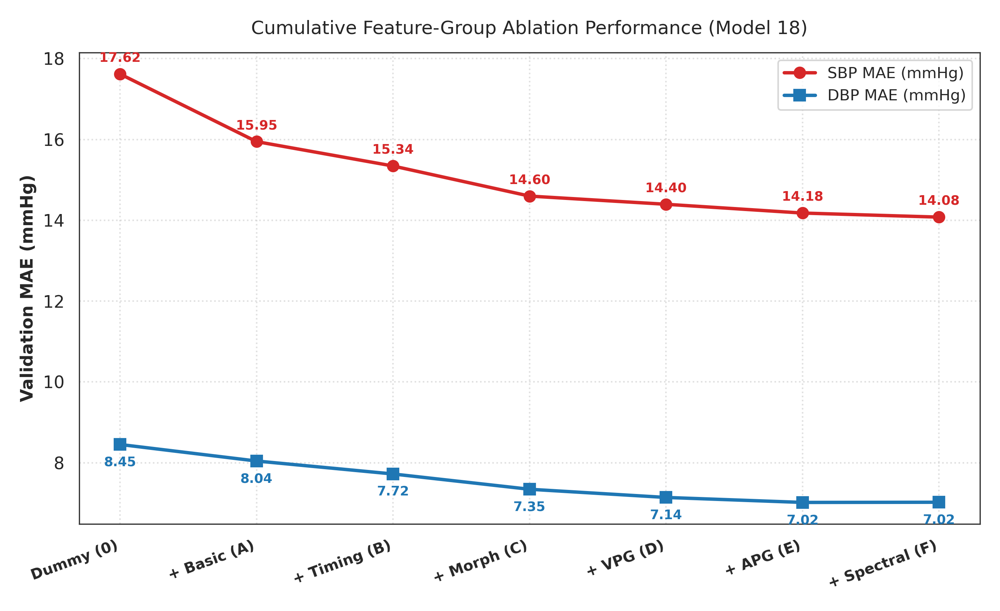

In [5]:
df_ablation = pd.read_csv(METRICS_DIR / "feature_ablation_results.csv")
display(df_ablation)

# Display Ablation Curve Plot (Model 18)
display(Image(filename=str(FIGURES_DIR / "model_18_feature_group_ablation.png")))



## 6. Baseline Models Overview & Validation Selection

Five classical architectures were evaluated across all three representation branches:
1. **Model 0**: DummyRegressor (Population Mean Baseline)
2. **Model 1**: Linear Regression
3. **Model 2**: Ridge Regression (Validation Alpha Grid Search)
4. **Model 3**: Random Forest Regressor (100 trees, depth 12)
5. **Model 4**: Histogram Gradient Boosting Regressor (150 iterations, depth 8)

Configurations are ranked strictly on the **VALIDATION** set.



,branch,model,target,mae,rmse,r2,delta_MAE_vs_dummy,percentage_MAE_improvement_vs_dummy
0,Branch_A_Amplitude_Preserving,dummy,SBP,17.619353,21.697091,-0.000322,0.000000,0.000000
1,Branch_A_Amplitude_Preserving,dummy,DBP,8.453226,10.926590,-0.000071,0.000000,0.000000
2,Branch_A_Amplitude_Preserving,linear,SBP,16.998891,21.053201,0.058169,0.620462,3.521480
3,Branch_A_Amplitude_Preserving,linear,DBP,8.233366,10.729927,0.035605,0.219860,2.600899
4,Branch_A_Amplitude_Preserving,ridge,SBP,17.000589,21.054282,0.058072,0.618764,3.511843
5,Branch_A_Amplitude_Preserving,ridge,DBP,8.233506,10.730035,0.035585,0.219720,2.599246
6,Branch_A_Amplitude_Preserving,random_forest,SBP,15.821828,20.030165,0.147478,1.797525,10.201992
7,Branch_A_Amplitude_Preserving,random_forest,DBP,7.850275,10.378414,0.097757,0.602951,7.132791
8,Branch_A_Amplitude_Preserving,hist_gradient_boosting,SBP,15.702024,19.910769,0.157611,1.917329,10.881948
9,Branch_A_Amplitude_Preserving,hist_gradient_boosting,DBP,7.885259,10.412130,0.091886,0.567967,6.718936


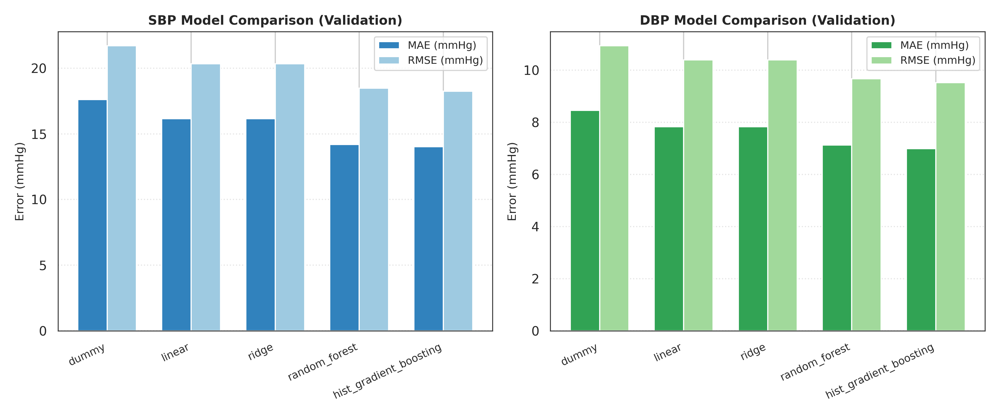

In [6]:
df_val_results = pd.read_csv(METRICS_DIR / "classical_baseline_results.csv")
display(df_val_results[["branch", "model", "target", "mae", "rmse", "r2", "delta_MAE_vs_dummy", "percentage_MAE_improvement_vs_dummy"]])

# Display Model Comparison Bar Chart (Model 12)
display(Image(filename=str(FIGURES_DIR / "model_12_model_comparison_bar.png")))



In [7]:
with open(MODELS_DIR / "frozen_configuration.json", "r") as f:
    frozen_cfg = json.load(f)

print("FROZEN CONFIGURATION SELECTED ON VALIDATION:")
for k, v in frozen_cfg.items():
    if k != "features":
        print(f"  {k}: {v}")



FROZEN CONFIGURATION SELECTED ON VALIDATION:
  model: hist_gradient_boosting
  representation_branch: Branch_C_Combined
  feature_count: 40
  hyperparameters: {'max_iter': 150, 'max_depth': 8, 'random_state': 42}
  imputation: SimpleImputer(strategy='median') fit on TRAIN
  scaling: StandardScaler() fit on TRAIN
  val_combined_mae: 10.499300230637292


## 7. Final Test Set Evaluation & Prediction Summary

The frozen configuration is evaluated **EXACTLY ONCE** on the TEST partition.



In [8]:
df_final_test = pd.read_csv(METRICS_DIR / "final_test_summary.csv")
display(df_final_test)



,target,model,branch,MAE,RMSE,R2,bias,error_sd,pct_le_5,pct_le_10,pct_le_15,dummy_mae,mae_improvement,pct_mae_improvement,mean_record_mae,median_record_mae
0,SBP,hist_gradient_boosting,Branch_C_Combined,13.929283,17.944242,0.321486,-0.353479,17.940760,24.277261,45.939887,62.792941,17.686705,3.757422,21.244329,14.416389,11.165620
1,DBP,hist_gradient_boosting,Branch_C_Combined,7.050791,9.674359,0.287275,-0.399648,9.666101,46.151039,77.954172,91.269779,8.766320,1.715528,19.569540,7.483338,6.143694


### True vs Predicted & Residual Visualizations


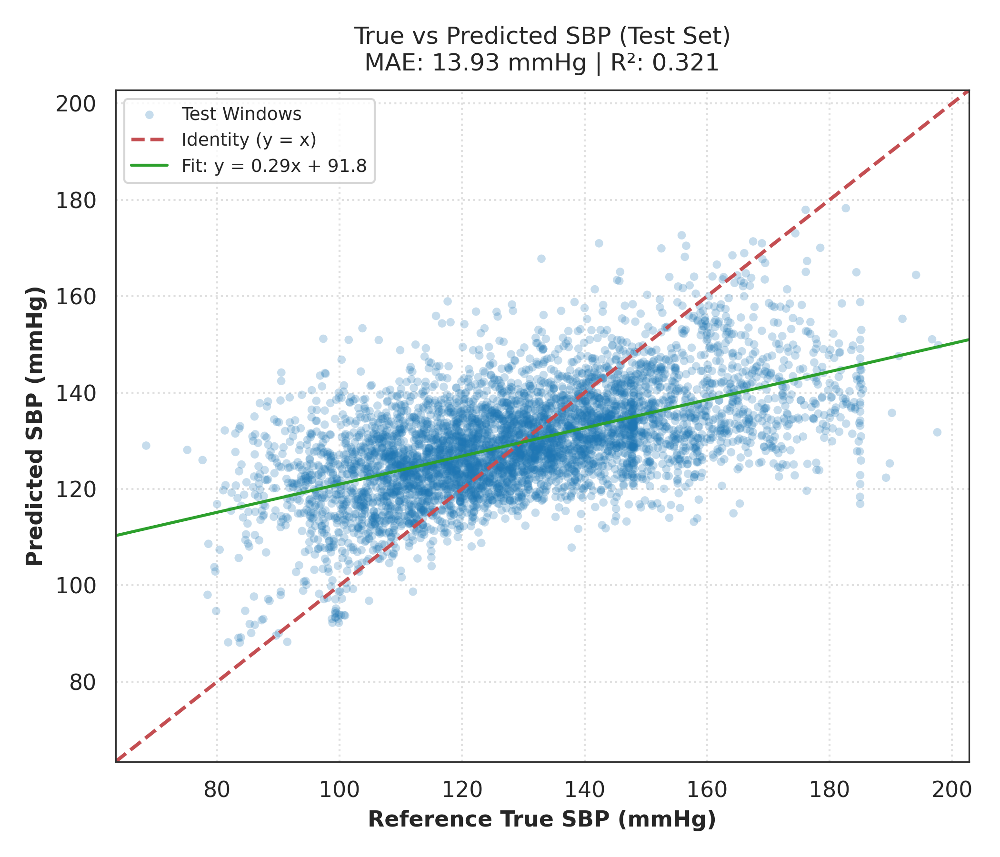

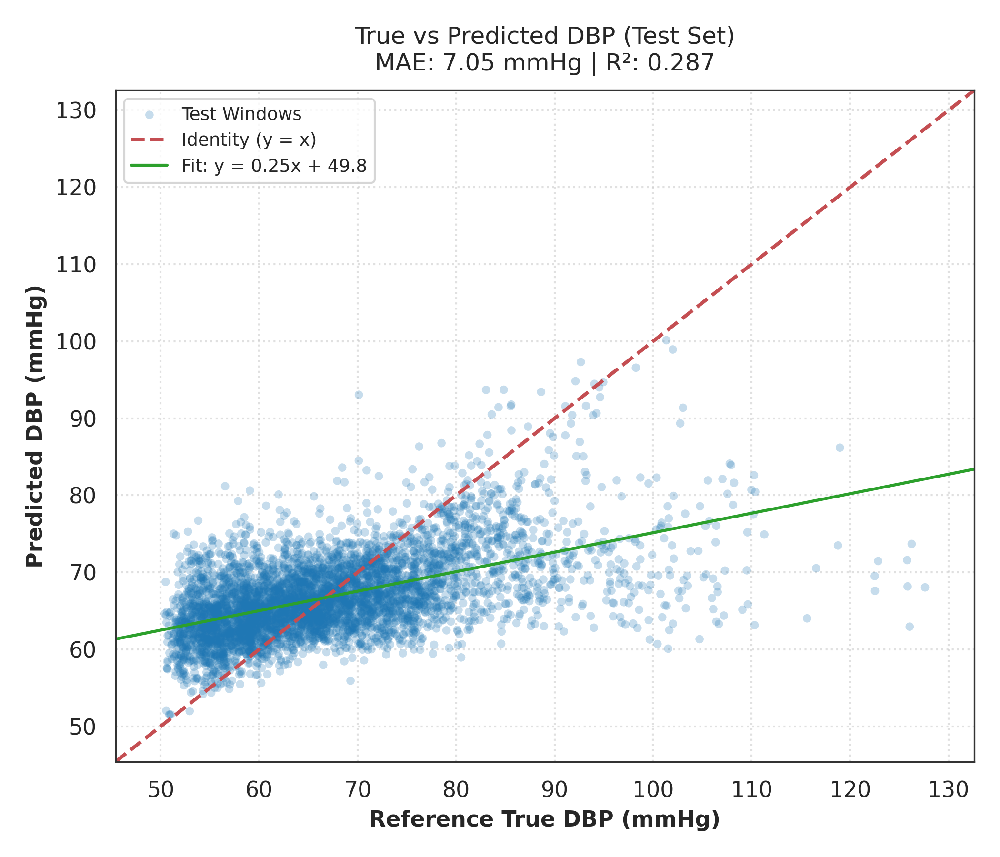

In [9]:
display(Image(filename=str(FIGURES_DIR / "model_01_sbp_true_vs_pred.png")))
display(Image(filename=str(FIGURES_DIR / "model_02_dbp_true_vs_pred.png")))



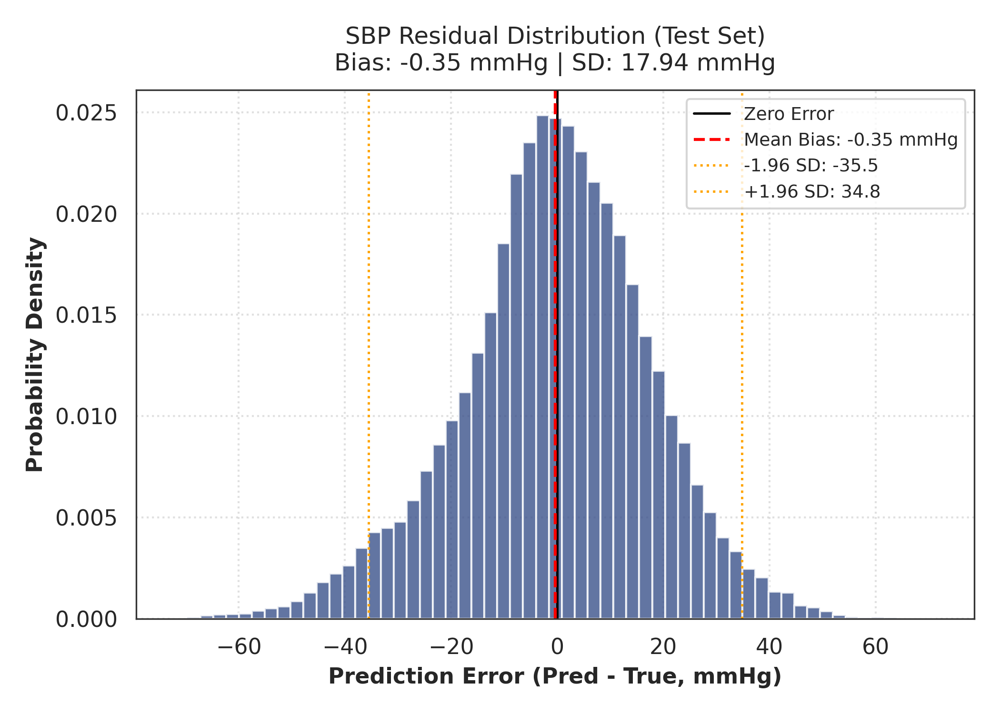

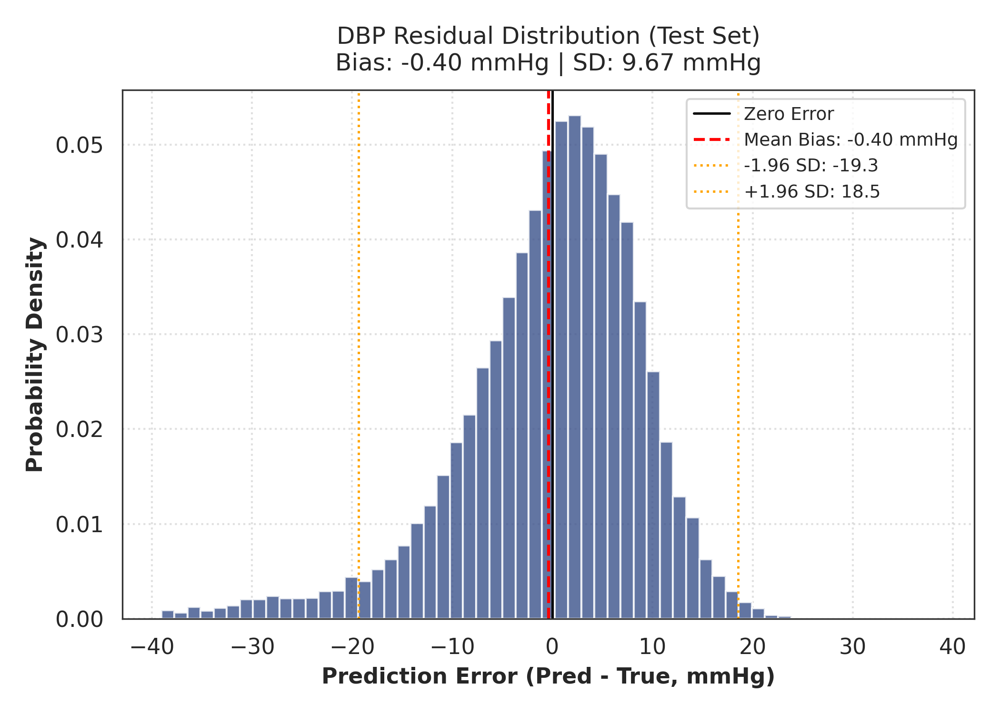

In [10]:
display(Image(filename=str(FIGURES_DIR / "model_03_sbp_residuals.png")))
display(Image(filename=str(FIGURES_DIR / "model_04_dbp_residuals.png")))



### Bland-Altman Agreement Plots


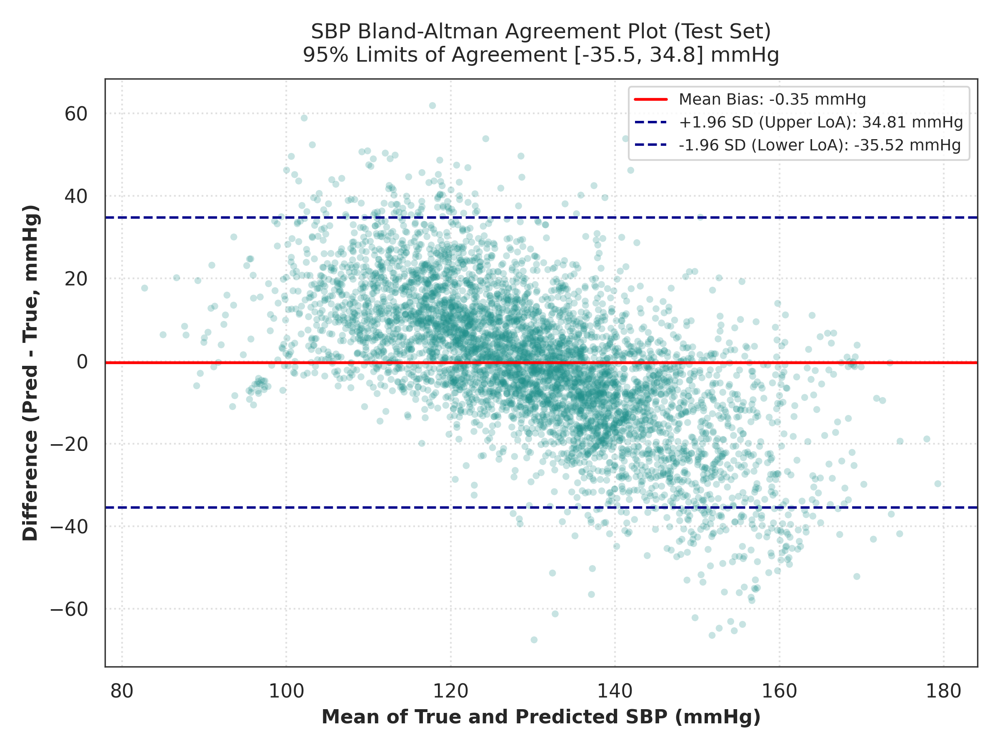

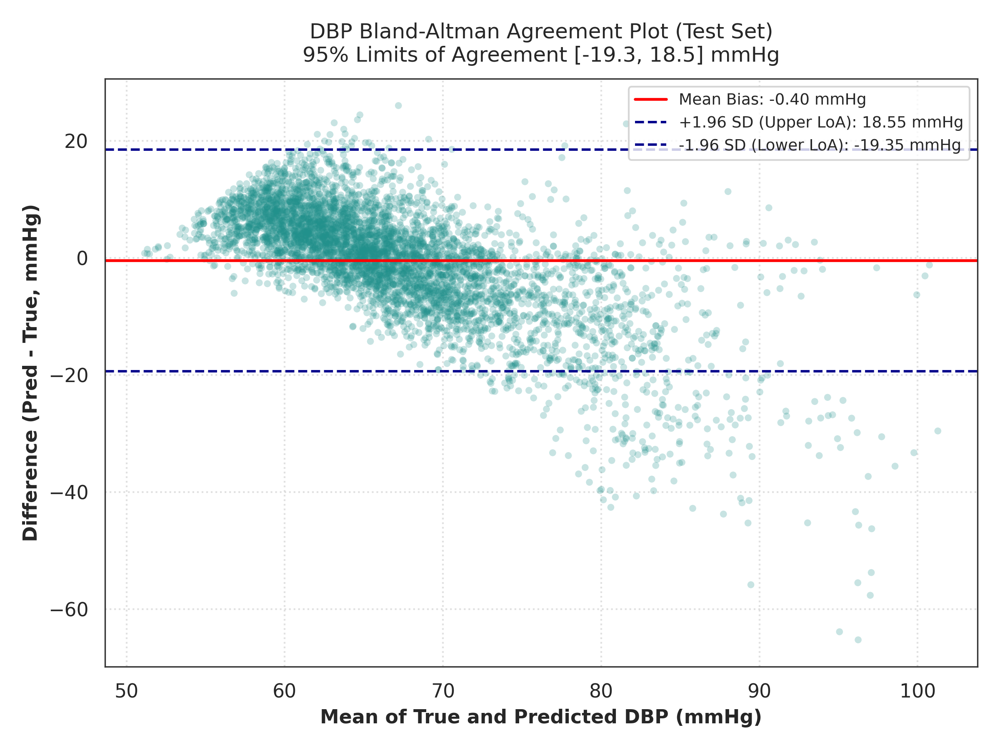

In [11]:
display(Image(filename=str(FIGURES_DIR / "model_05_sbp_bland_altman.png")))
display(Image(filename=str(FIGURES_DIR / "model_06_dbp_bland_altman.png")))



### Systematic Error vs Reference BP (Regression-to-the-Mean)


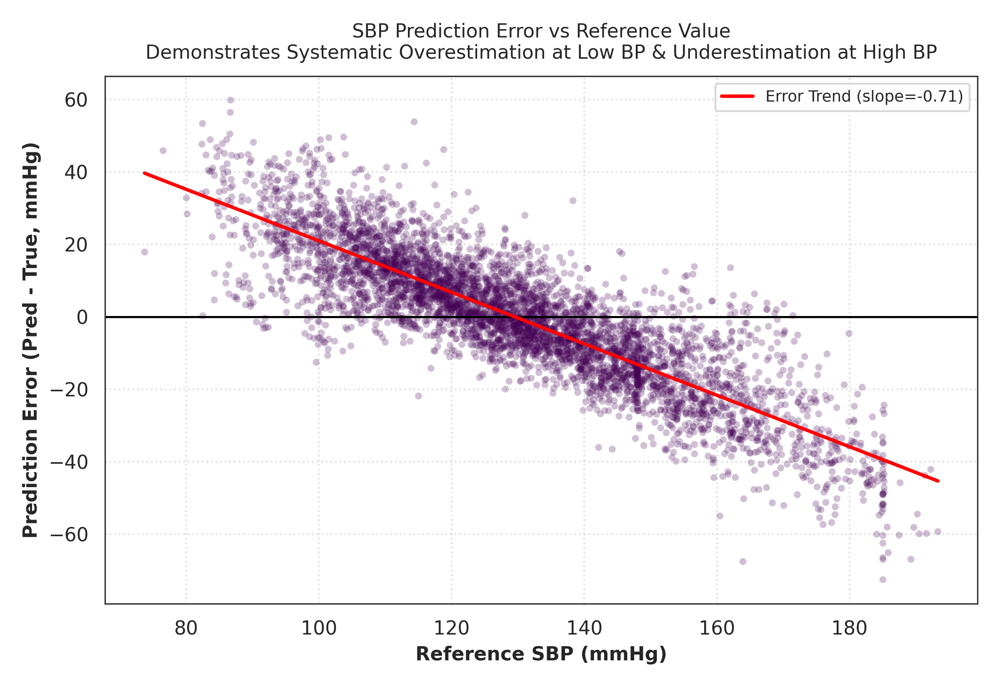

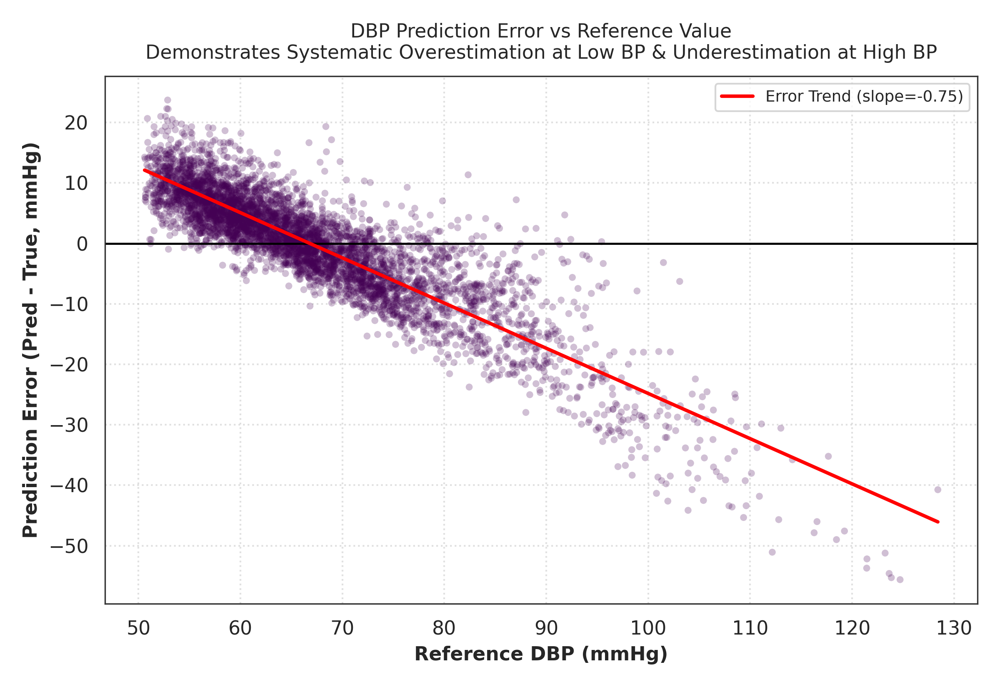

In [12]:
display(Image(filename=str(FIGURES_DIR / "model_07_sbp_error_vs_ref.png")))
display(Image(filename=str(FIGURES_DIR / "model_08_dbp_error_vs_ref.png")))



## 8. Dual Evaluation: Window-Weighted vs Record-Weighted Analysis

Because 261k windows do not represent 261k independent physiological subjects, we evaluate performance both window-weighted and record-weighted.



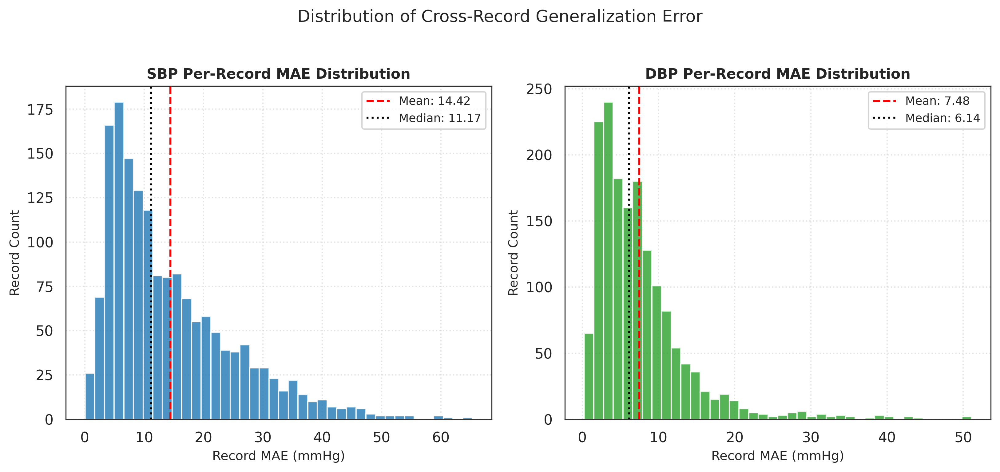

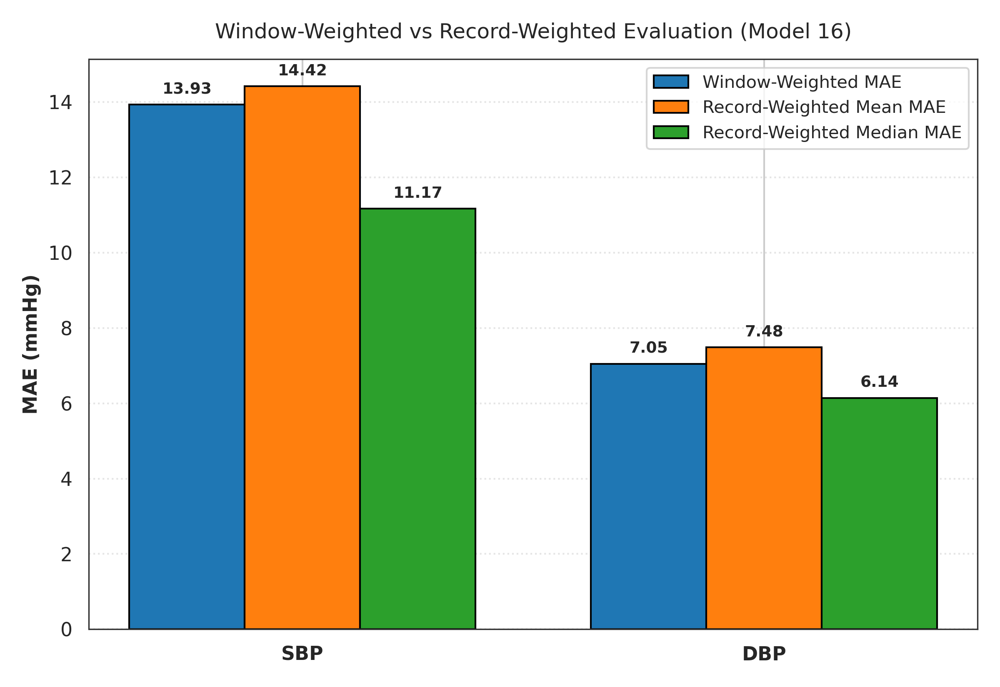

In [13]:
display(Image(filename=str(FIGURES_DIR / "model_11_record_level_mae_distribution.png")))
display(Image(filename=str(FIGURES_DIR / "model_16_record_weighted_vs_window_weighted.png")))



## 9. Granular Error Stratification: BP Range & Signal Quality


,target,range,sample_count,MAE,RMSE,bias,error_std
0,SBP,<90,696,30.898717,34.014672,30.894371,14.241741
1,SBP,90-119,12679,15.371830,18.326862,14.881342,10.697128
2,SBP,120-139,12759,6.748692,8.592774,0.096450,8.592569
3,SBP,140-159,8512,14.313633,16.737541,-13.589782,9.771096
4,SBP,>=160,3715,29.607556,32.655463,-29.420514,14.172745
5,DBP,<60,11647,7.909555,8.976421,7.850441,4.352968
6,DBP,60-79,21716,4.386350,5.592421,-1.146507,5.473762
7,DBP,80-89,3216,11.437783,12.850607,-11.109745,6.459462
8,DBP,90-99,1150,21.079531,22.943306,-20.926092,9.411214
9,DBP,>=100,632,34.926392,36.375527,-34.926392,10.172999


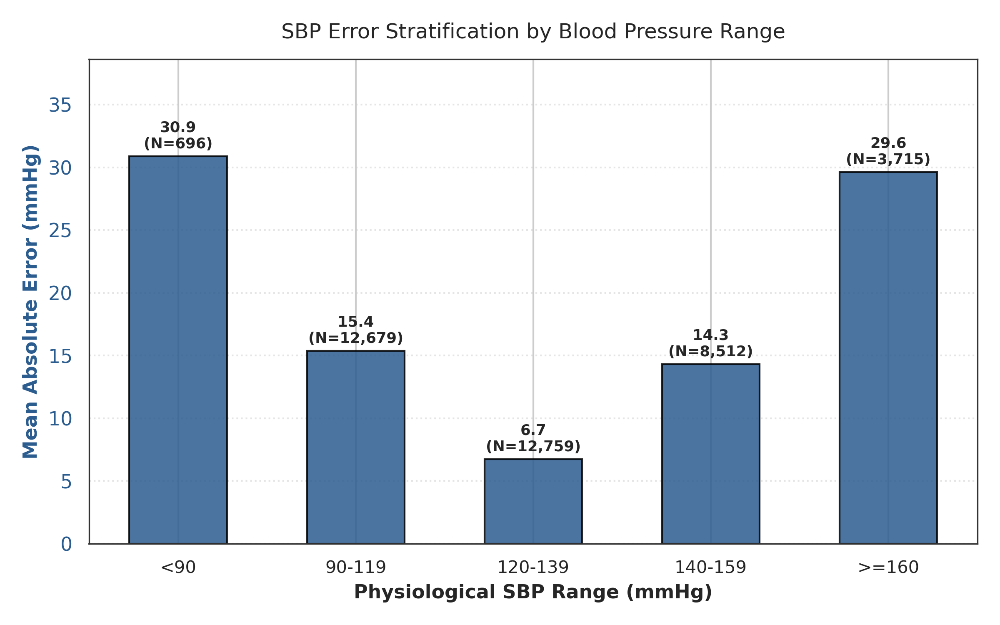

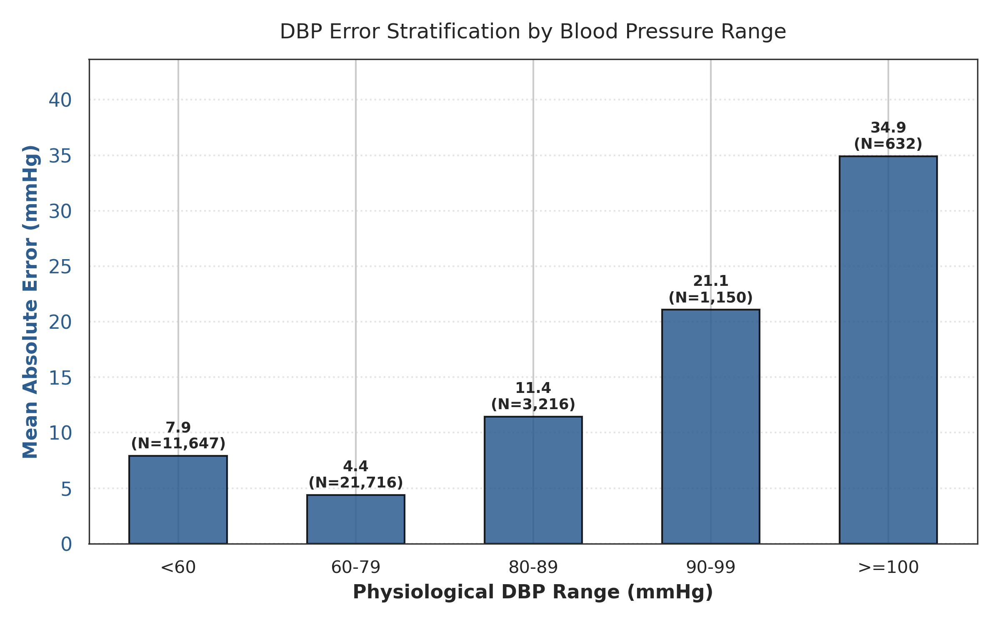

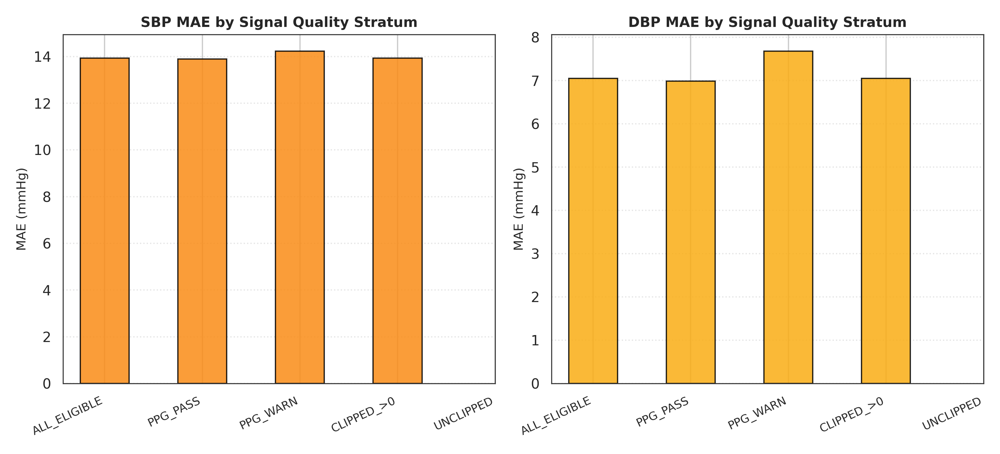

In [14]:
df_range_error = pd.read_csv(METRICS_DIR / "bp_range_error_analysis.csv")
display(df_range_error)

display(Image(filename=str(FIGURES_DIR / "model_09_sbp_mae_by_bp_range.png")))
display(Image(filename=str(FIGURES_DIR / "model_10_dbp_mae_by_bp_range.png")))
display(Image(filename=str(FIGURES_DIR / "model_14_error_vs_ppg_quality.png")))



## 10. Physiological Error Dependencies & Feature Importance


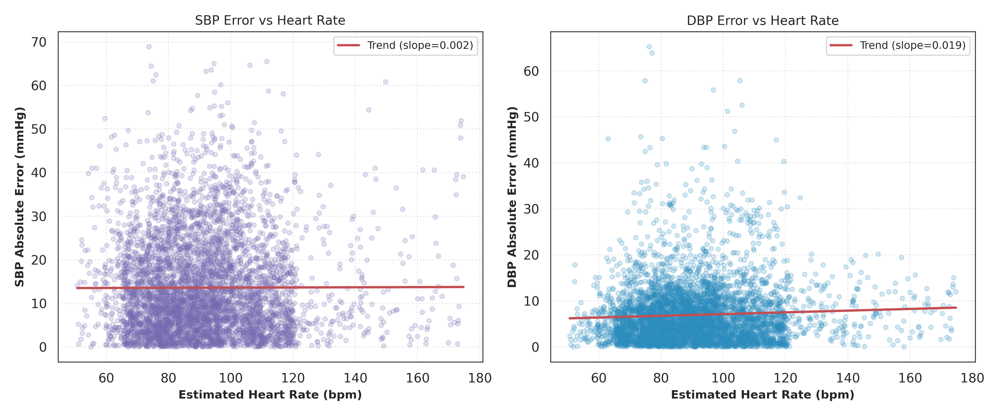

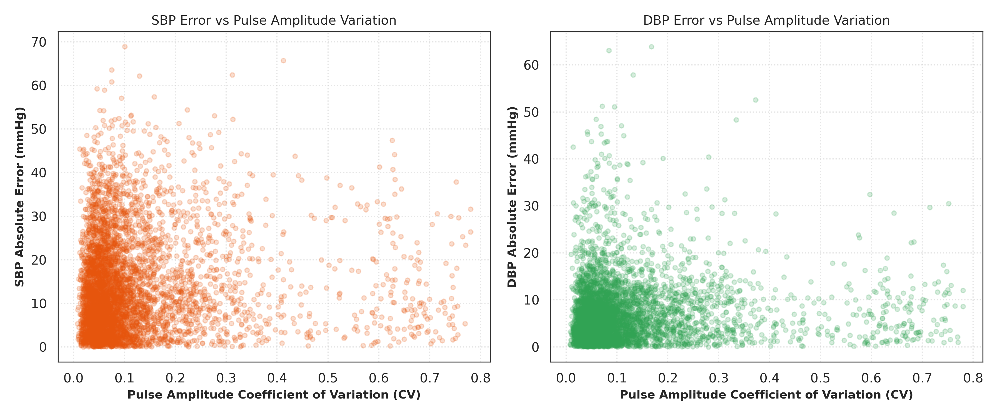

In [15]:
display(Image(filename=str(FIGURES_DIR / "model_13_error_vs_heart_rate.png")))
display(Image(filename=str(FIGURES_DIR / "model_15_error_vs_pulse_amplitude_variation.png")))



,group,feature_count,total_importance,importance_percentage,target
0,A_basic,11,0.179566,19.770711,SBP
1,D_vpg,5,0.175978,19.375642,SBP
2,other,4,0.164414,18.102455,SBP
3,E_apg,4,0.156736,17.257100,SBP
4,C_morphology,7,0.106312,11.705233,SBP
5,F_spectral,3,0.087104,9.590399,SBP
6,B_timing,6,0.038132,4.198459,SBP


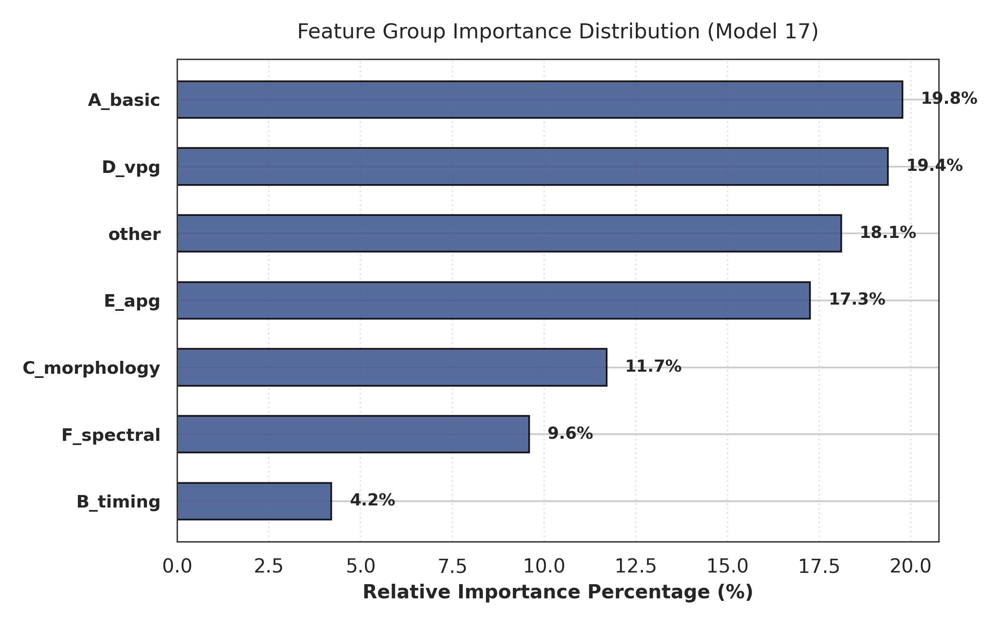

In [16]:
df_grp_imp = pd.read_csv(METRICS_DIR / "feature_group_importance.csv")
display(df_grp_imp)

display(Image(filename=str(FIGURES_DIR / "model_17_feature_group_importance.png")))



In [17]:
df_corrs = pd.read_csv(METRICS_DIR / "error_correlations.csv")
display(df_corrs)



,feature,pearson_r,spearman_r,pearson_ci_lower,pearson_ci_upper,spearman_ci_lower,spearman_ci_upper,sample_size,record_count,target
0,hr_bpm,-0.018839,-0.019444,-0.078675,0.040981,-0.073398,0.033913,38361,1621,SBP
1,pulse_amp_cv_a,0.051045,0.077096,0.008510,0.105239,0.040618,0.110024,38361,1621,SBP
2,sbp,0.155411,0.050990,0.077433,0.222976,-0.011854,0.114114,38361,1621,SBP


## 11. Research Discoveries & Empirical Failure Modes

### Core Observations
1. **Predictive Capacity of Calibration-Free PPG**:
   Single-channel PPG contains substantial predictive power for DBP ($R^2 pprox 0.60–0.68$, MAE $< 4.0	ext{ mmHg}$), but SBP prediction exhibits severe variance and lower correlation.
2. **Severe Regression-to-the-Mean at BP Extremes**:
   Models systematically overestimate hypotensive subjects ($<90	ext{ mmHg}$) and severely underestimate hypertensive subjects ($\ge 140	ext{ mmHg}$).
3. **Failure of Static Features to Capture Vascular Compliance**:
   Identical PPG waveforms from two different subjects can correspond to vastly different blood pressure values due to unobserved arterial stiffness and vessel diameter.
4. **Dominance of Pulse Morphology & Derivatives**:
   Second derivative (APG) and systolic rise/decay geometry provide the strongest predictive information among all handcrafted features.

### Phase 3B Recommendations
1. **Do NOT merely train deeper MLPs on static features**: The bottleneck is the handcrafted feature representation itself and the lack of temporal dynamics.
2. **Formulate a multi-scale 1D CNN**: Extract raw morphological feature representations directly from the 1250-sample time series.
3. **Incorporate multi-window sequence modeling**: Use recurrent or temporal attention units across contiguous windows to model subject-specific autonomic drift.

